In [1]:
import pandas as pd
import numpy as np
from helpers import feature_importance_xgb, bin_pipe, new_col_pipe, target_enc_pipe, outliers_pipe
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from joblib import dump, load

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae, mean_absolute_percentage_error as mape, r2_score
from category_encoders import CountEncoder
from category_encoders.target_encoder import TargetEncoder
seed = 42

In [2]:
# Загрузим данные и результаты baseline
data = pd.read_csv('diamonds.csv')
result_cross_val_baseline = load('result_cross_val_baseline.joblib')
result_test_baseline = load('result_test_baseline.joblib')

### Feature engineering
Далее мы будем создавать новые, либо изменять старые признаки для улучшения метрик моделей.
Для обучения моделей на измененных признаках - будем использовать в качестве основы пайплайн с предыдущего шага (baseline) 

## Бинаризация 
Бинаризуем признак depth и table (удалив оригинальные столбцы).

In [12]:
df = data.copy()
df.drop(columns=['Unnamed: 0', 'x', 'y', 'z'], inplace=True)
# бинаризируем признаки depth и table
depth_bins = [43,50,55,60,65,70,1000]
depth_labels = ['<50', '50-54', '55-59', '60-64', '65-69', '70+']
df['depth'] = pd.cut(df['depth'], bins=depth_bins, labels = depth_labels)

table_bins = [43,50,60,70,80,90,1000]
table_labels = ['<50', '50-59', '60-69', '70-79', '80-89', '90+']
df['table'] = pd.cut(df['table'], bins=table_bins, labels = table_labels)

In [4]:
result_cross_val_bin_count, result_test_bin_count, models_bin_count = bin_pipe(df)

In [5]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_bin_count)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_bin_count)
print('')
print('Результаты на тестовой выборке baseline')
print('')
display(result_test_baseline)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_test_bin_count - result_test_baseline)


Результаты на кросс-валидации



,r2,mse,mae,mape,rsme
XGBoost,0.9776 ± 0.0008,355898.7625 ± 11112.1813,302.3987 ± 3.5012,0.0838 ± 0.001,596.5008 ± 9.2497



Результаты на тестовой выборке



,r2,mse,mae,mape,rsme
XGBoost,0.978493,341890.5,296.148834,0.083354,584.714033



Результаты на тестовой выборке baseline



,r2,mse,mae,mape,rsme
XGBoost,0.978765,337576.375,295.337585,0.083433,581.013231



Сравнение полученного результата с baseline



,r2,mse,mae,mape,rsme
XGBoost,-0.000271,4314.125,0.811249,-0.000079,3.700801


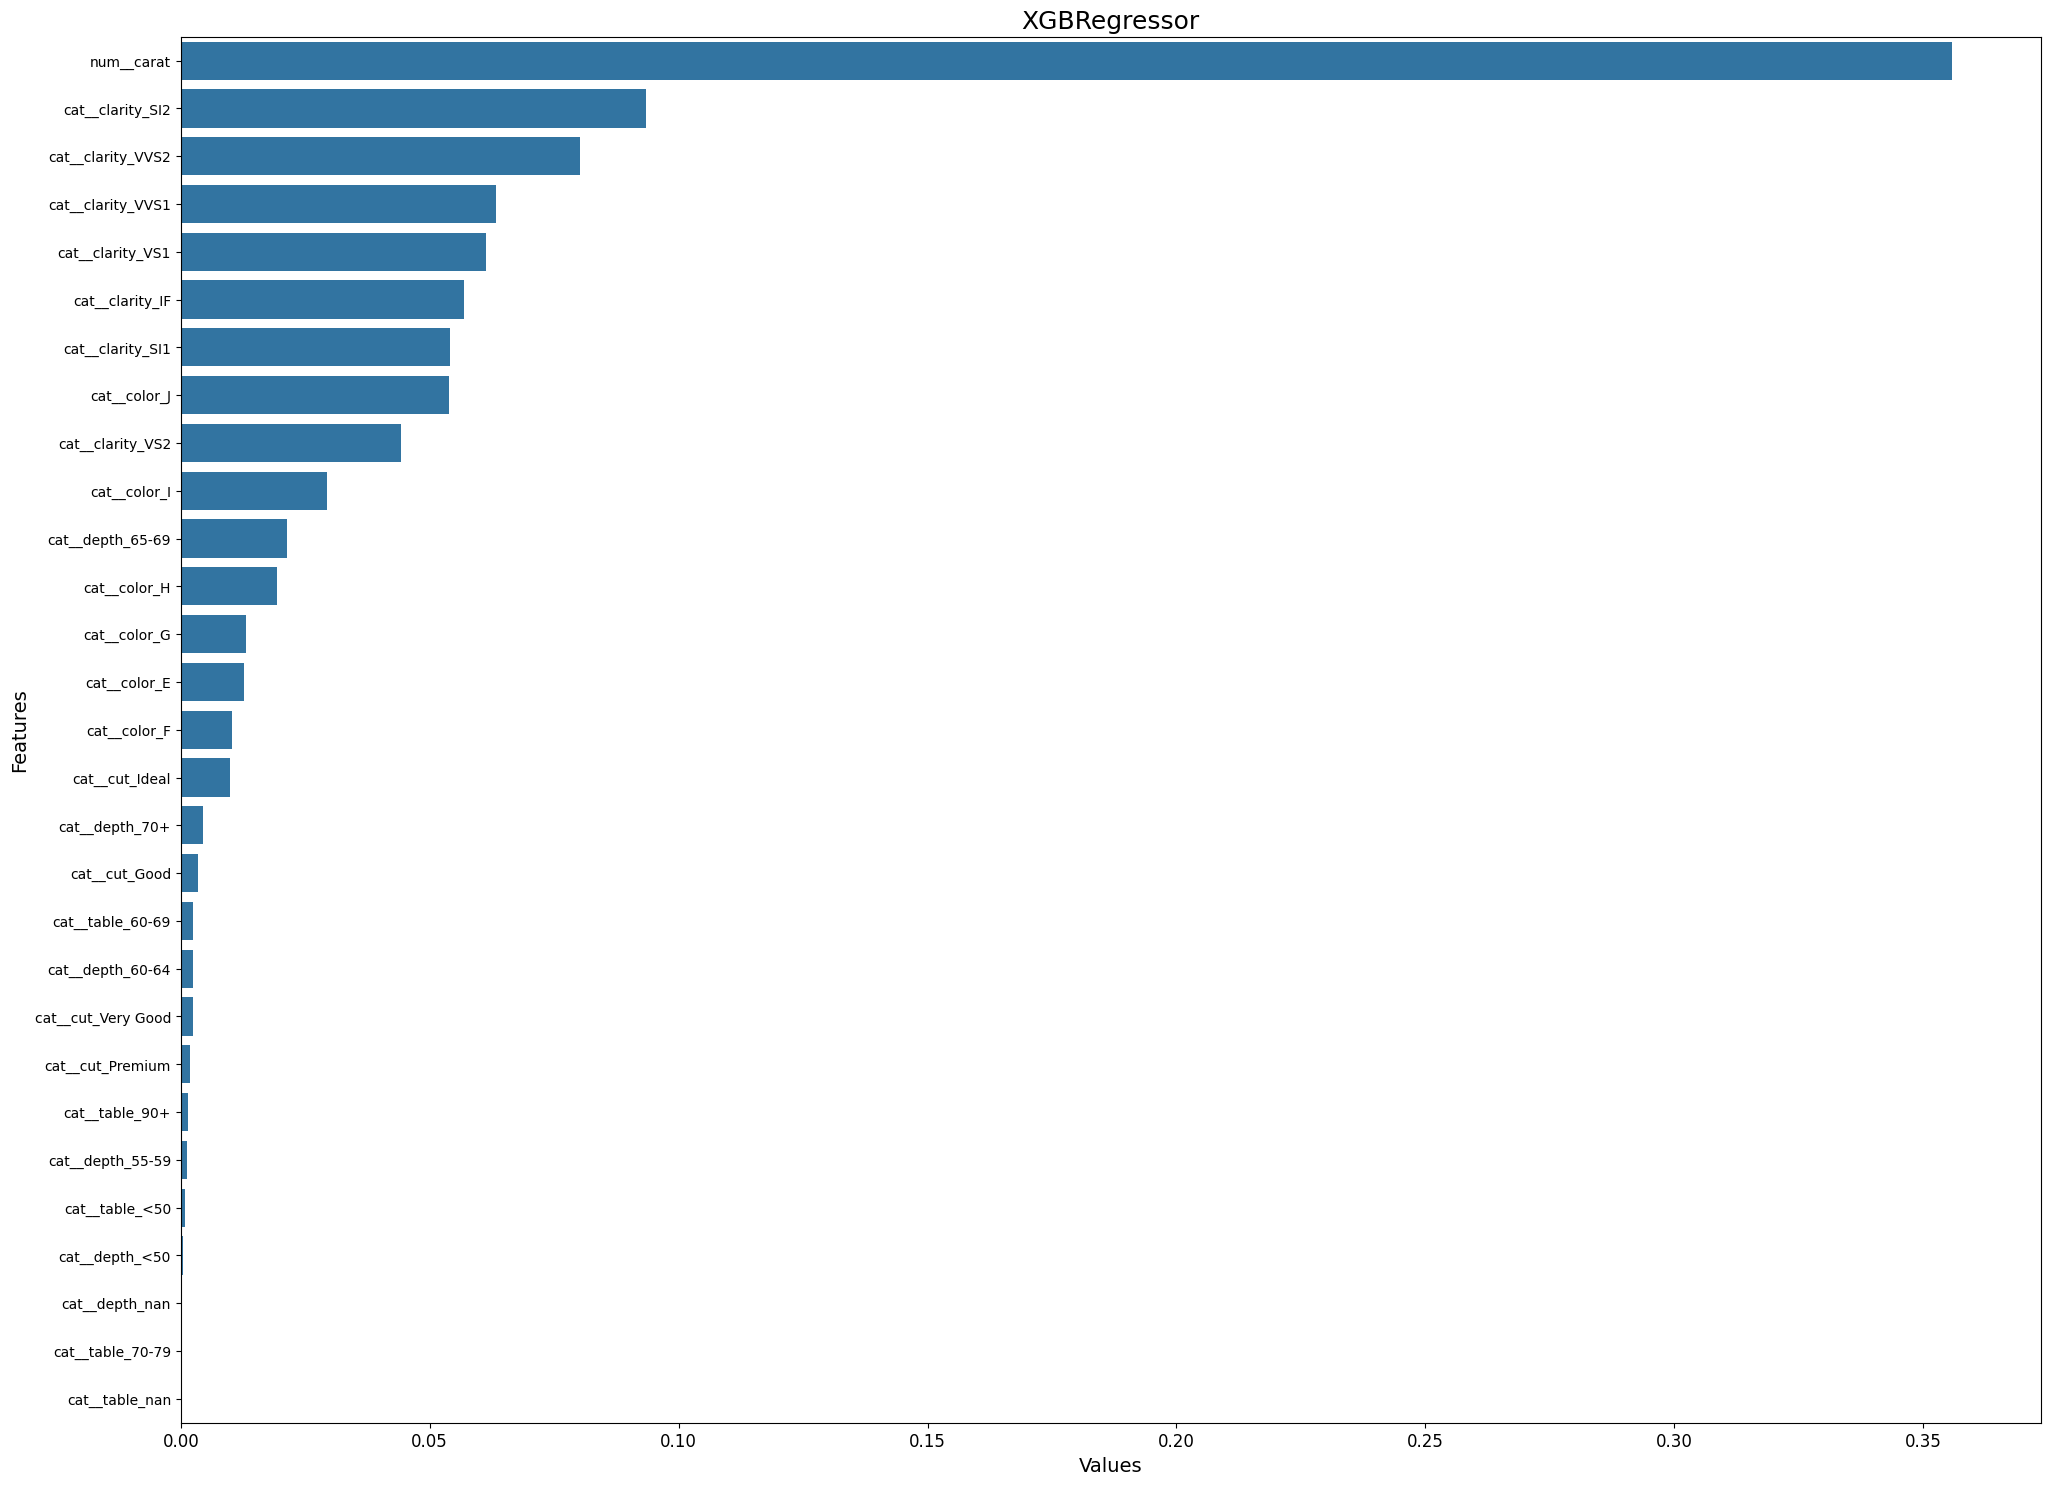

In [8]:
feature_importance_xgb(models_bin_count)

## Новые колонки

Создадим ряд новых колонок

In [3]:
df = data.copy()
# Получим новую колонку volume путем перемножения колонок x*y*z
df['volume'] = df['x']*df['y']*df['z']
df.drop(columns=['Unnamed: 0', 'x', 'y', 'z'], inplace=True)

In [4]:
df

,carat,cut,color,clarity,depth,table,price,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335,51.917250
...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,115.920000
53936,0.72,Good,D,SI1,63.1,55.0,2757,118.110175
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,114.449728
53938,0.86,Premium,H,SI2,61.0,58.0,2757,140.766120


In [5]:
result_cross_val_new_col, result_test_new_col, list_of_models_new_col = new_col_pipe(df)

In [7]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_new_col)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_new_col)
print('')
print('Результаты на тестовой выборке baseline')
print('')
display(result_test_baseline)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_test_new_col - result_test_baseline)


Результаты на кросс-валидации



,r2,mse,mae,mape,rsme
XGBoost,0.9776 ± 0.0008,356781.3812 ± 9326.0516,303.3427 ± 4.0608,0.0853 ± 0.0013,597.261 ± 7.7892



Результаты на тестовой выборке



,r2,mse,mae,mape,rsme
XGBoost,0.978826,336597.78125,294.236694,0.083956,580.170476



Результаты на тестовой выборке baseline



,r2,mse,mae,mape,rsme
XGBoost,0.978765,337576.375,295.337585,0.083433,581.013231



Сравнение полученного результата с baseline



,r2,mse,mae,mape,rsme
XGBoost,0.000062,-978.59375,-1.100891,0.000523,-0.842755


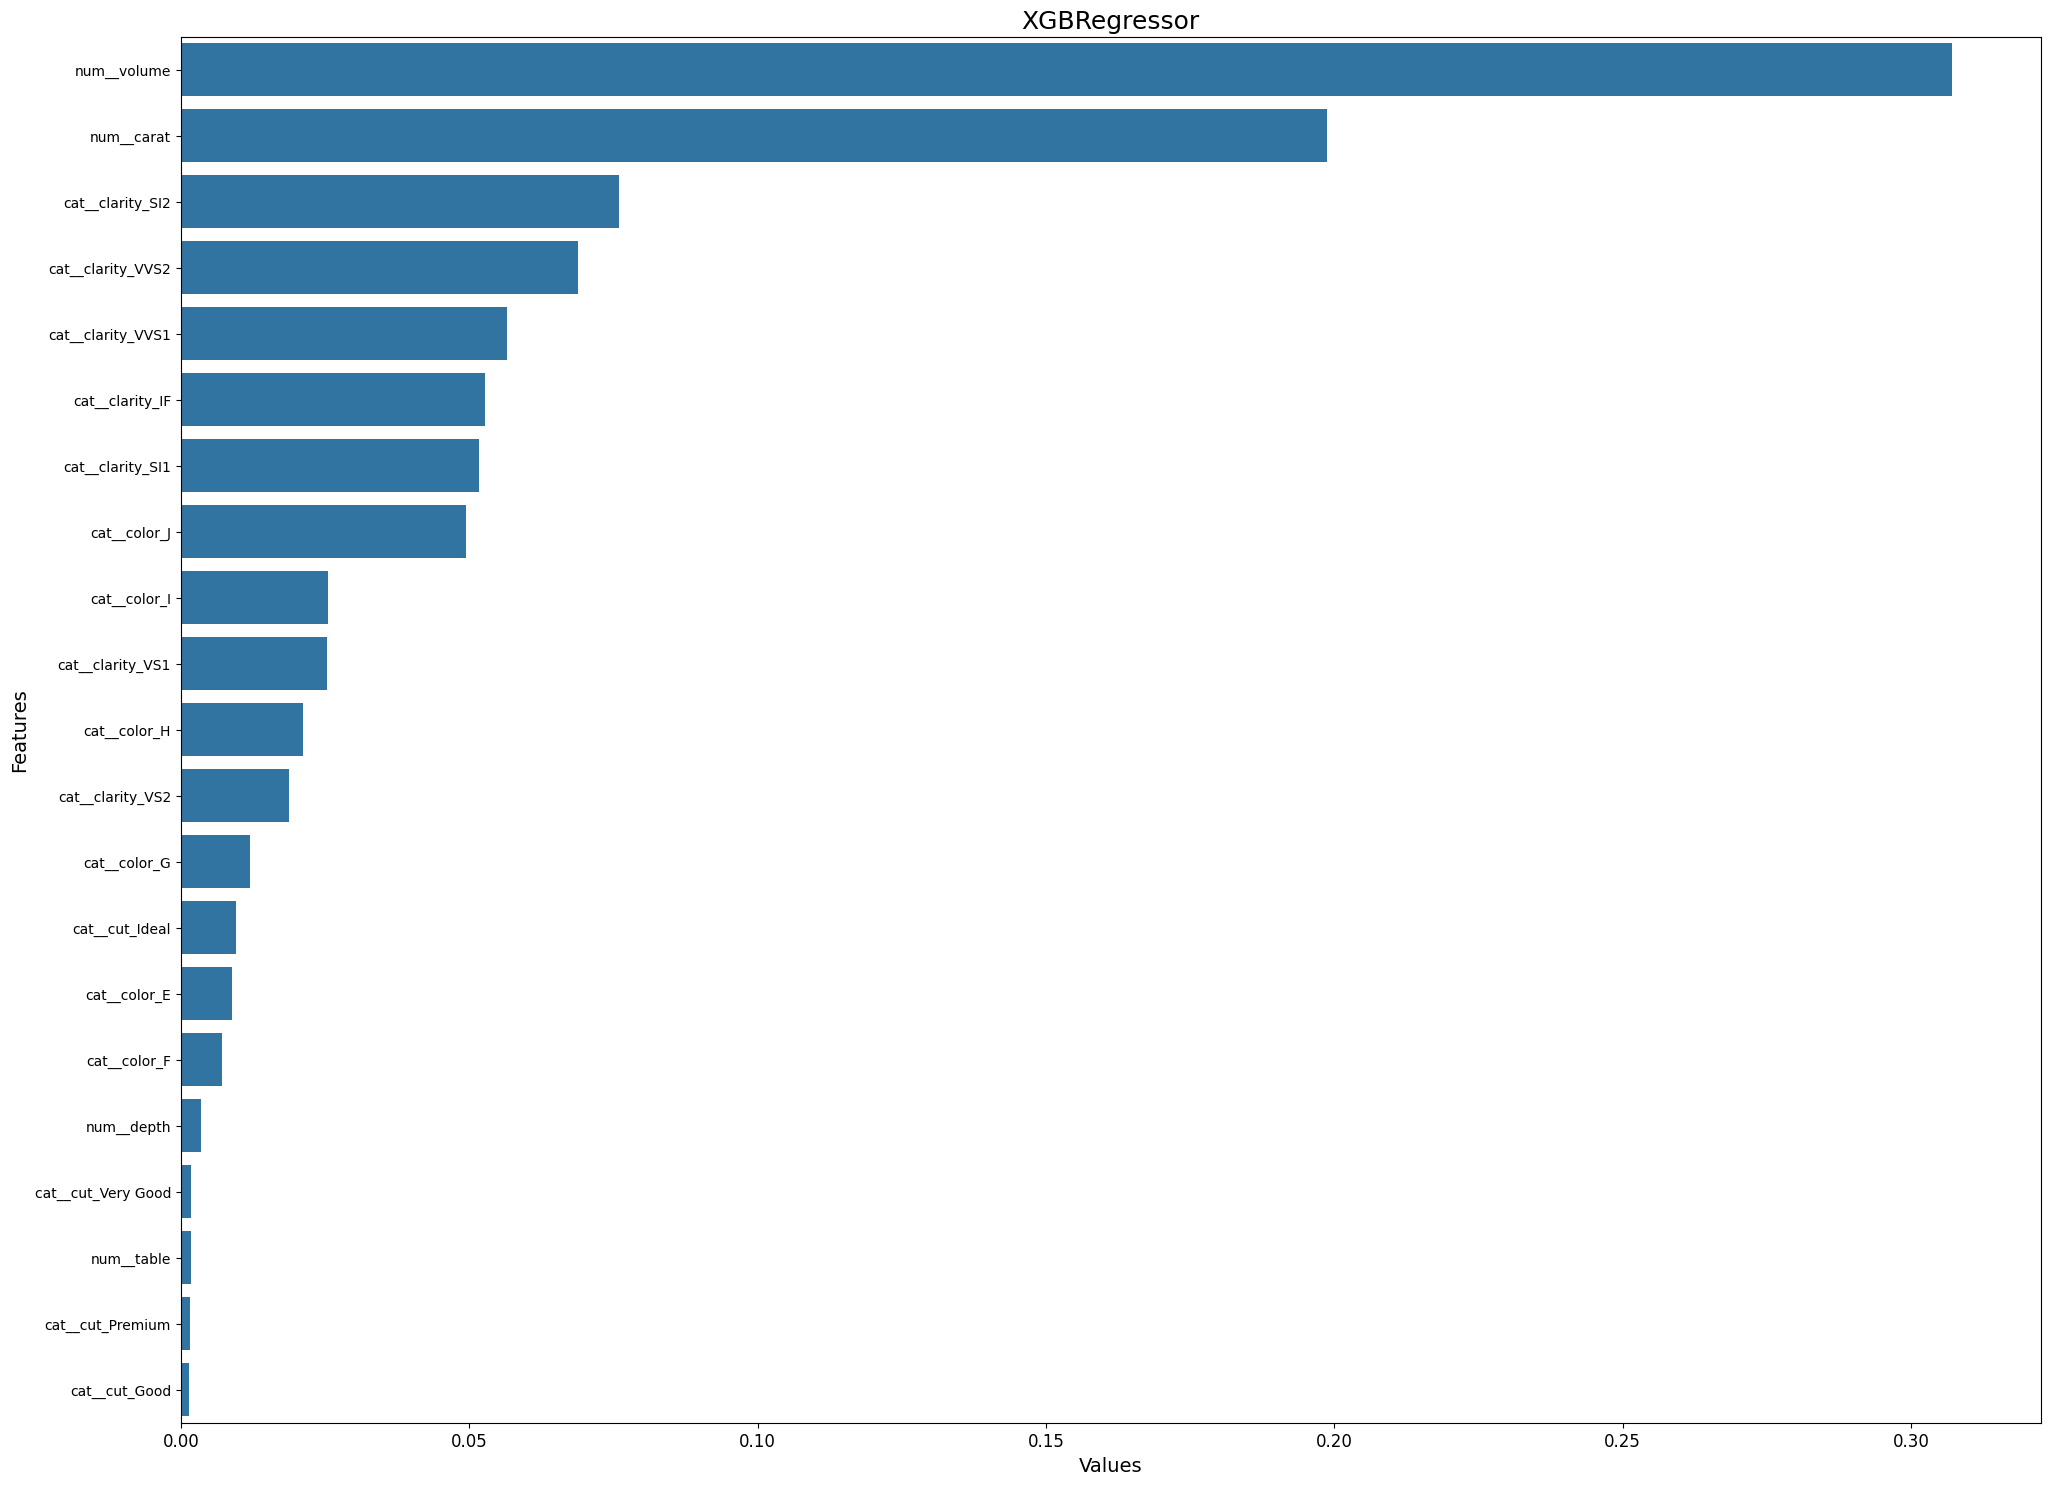

In [8]:
feature_importance_xgb(list_of_models_new_col)

## Target Encoding
Target Encoding это способ кодирования категориальных признаков, при котором каждой категории присваивается статистика по целевой переменной. В задаче классификации это вероятность класса. Создадим новые колонки с помощью TargetEncoder по колонкам duration (предварительно проведя бинаризацию), poutcome, education, contact. оригинальные колонки будут удалены из датасета (кроме цифровой колонки duration)

In [3]:
df = data.copy()
df.drop(columns=['Unnamed: 0', 'x', 'y', 'z'], inplace=True)

In [4]:
df

,carat,cut,color,clarity,depth,table,price
0,0.23,Ideal,E,SI2,61.5,55.0,326
1,0.21,Premium,E,SI1,59.8,61.0,326
2,0.23,Good,E,VS1,56.9,65.0,327
3,0.29,Premium,I,VS2,62.4,58.0,334
4,0.31,Good,J,SI2,63.3,58.0,335
...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757
53936,0.72,Good,D,SI1,63.1,55.0,2757
53937,0.70,Very Good,D,SI1,62.8,60.0,2757
53938,0.86,Premium,H,SI2,61.0,58.0,2757


In [5]:
result_cross_val_te, result_test_te, list_of_models_te = target_enc_pipe(df)

In [7]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_te)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_te)
print('')
print('Результаты на тестовой выборке baseline')
print('')
display(result_test_baseline)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_test_te - result_test_baseline)


Результаты на кросс-валидации



,r2,mse,mae,mape,rsme
XGBoost,0.9806 ± 0.0006,308434.9375 ± 11767.8435,284.4321 ± 5.3213,0.0787 ± 0.0008,555.2677 ± 10.6154



Результаты на тестовой выборке



,r2,mse,mae,mape,rsme
XGBoost,0.980918,303343.3125,282.206604,0.078598,550.766114



Результаты на тестовой выборке baseline



,r2,mse,mae,mape,rsme
XGBoost,0.978765,337576.375,295.337585,0.083433,581.013231



Сравнение полученного результата с baseline



,r2,mse,mae,mape,rsme
XGBoost,0.002153,-34233.0625,-13.130981,-0.004836,-30.247117


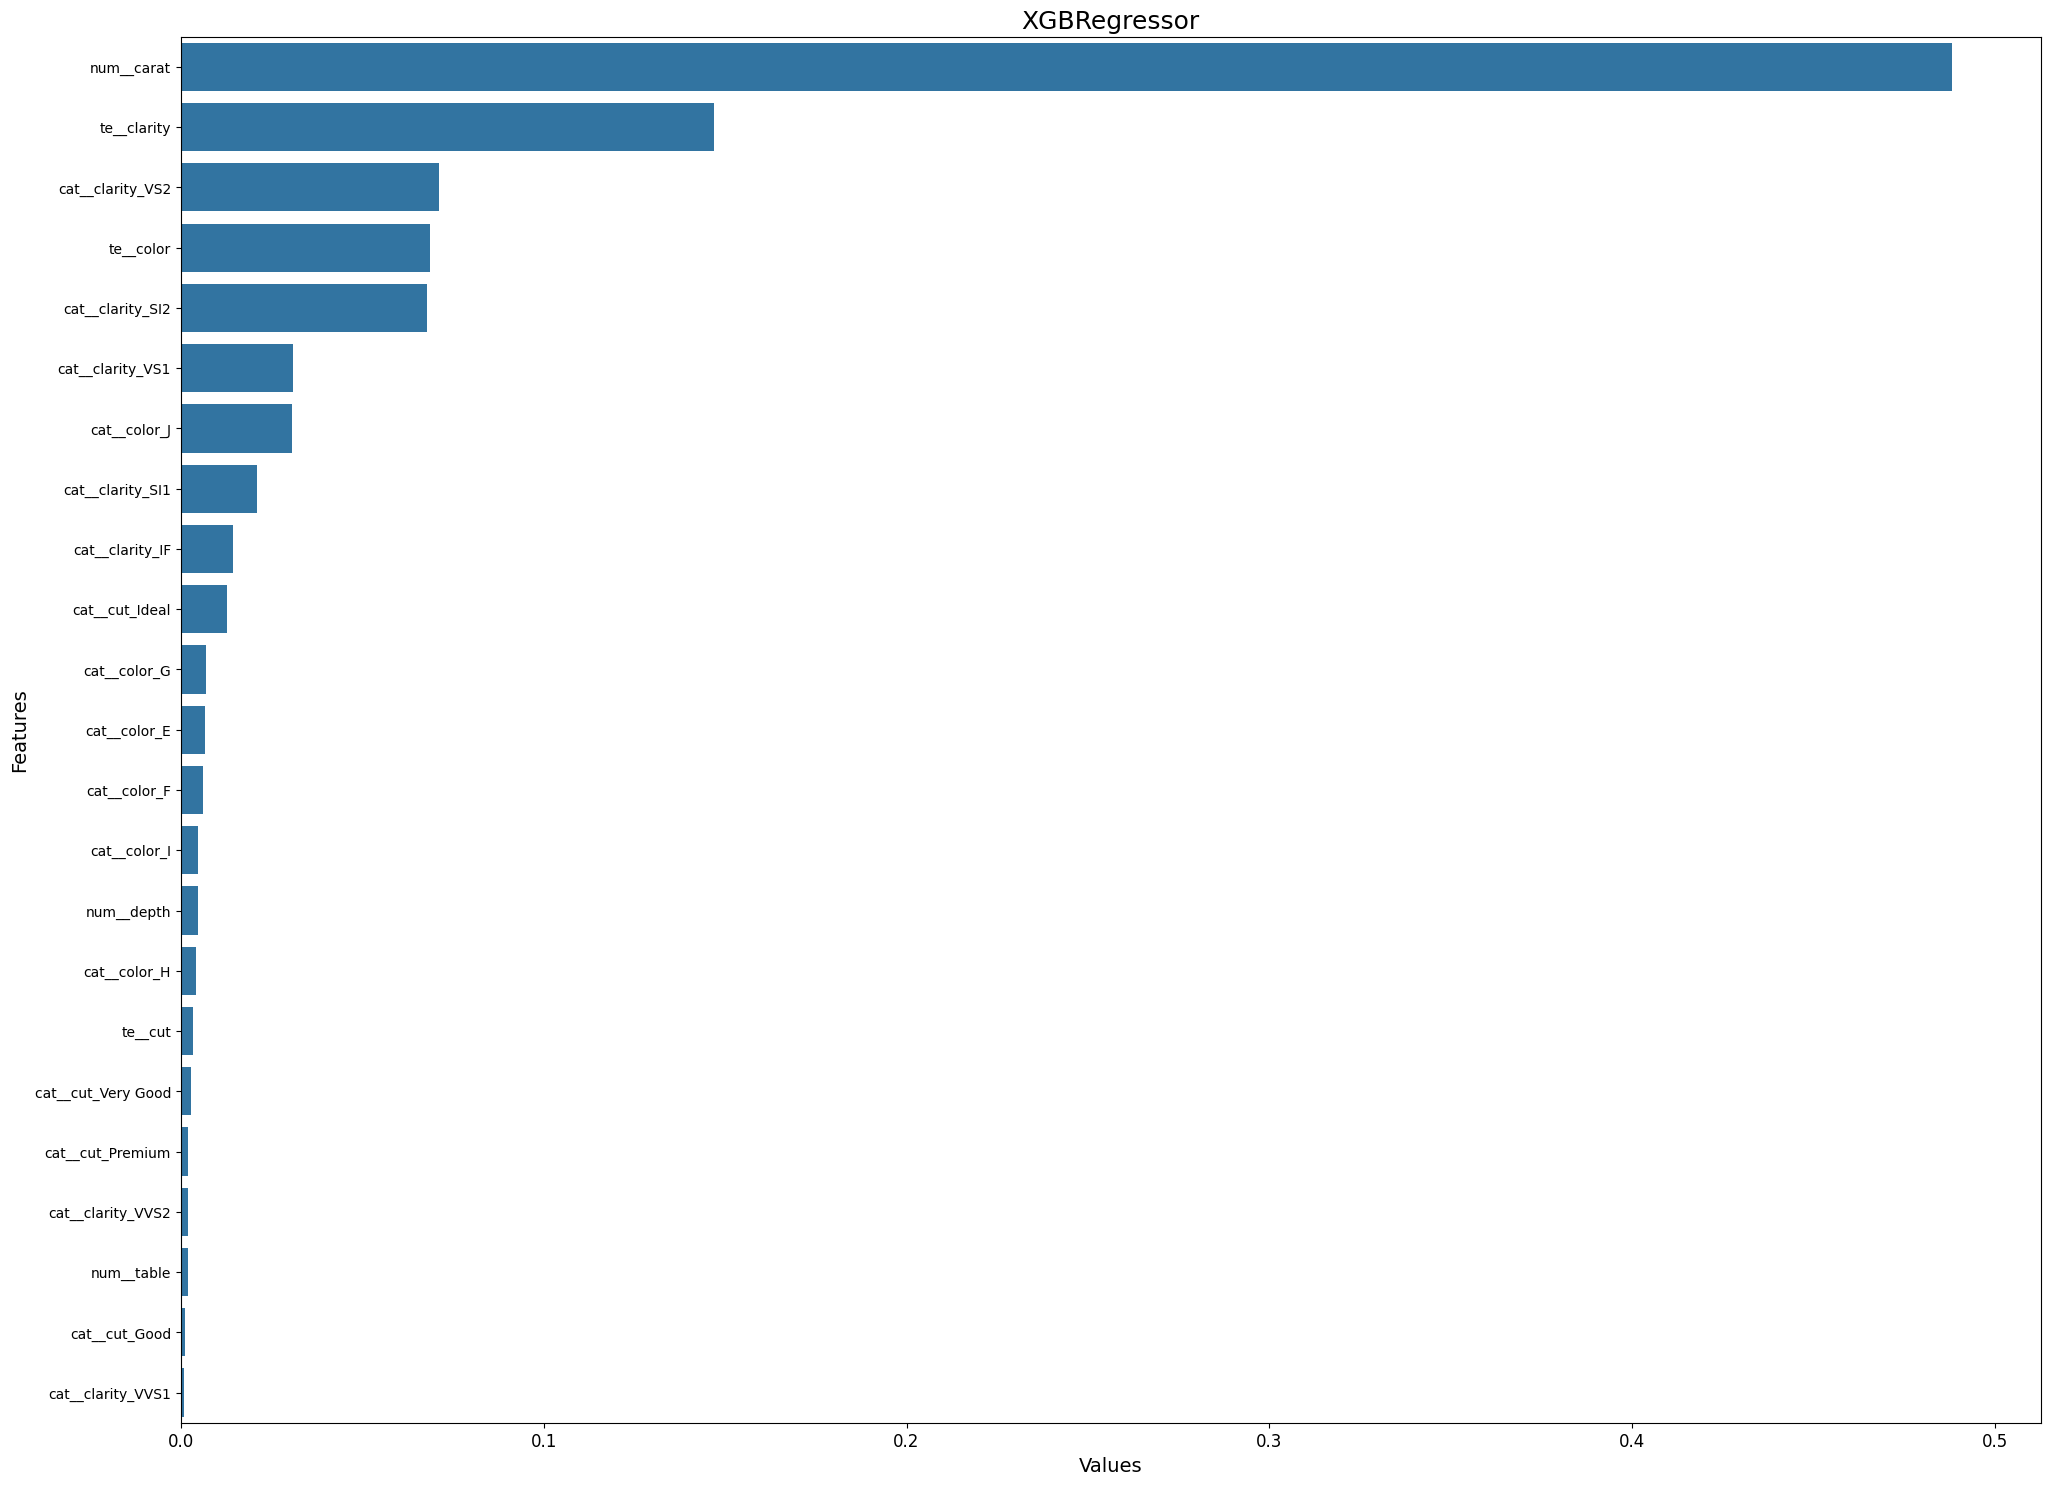

In [8]:
feature_importance_xgb(list_of_models_te)

## Обработка выбросов
Так как в датасете присутствуют выбросы попробуем заменить их экстремальные значения на 1-ый или 99-ый квантиль

In [3]:
df = data.copy()
df.drop(columns=['Unnamed: 0', 'x', 'y', 'z'], inplace=True)

In [4]:
result_cross_val_o, result_test_o, list_of_models_o = outliers_pipe(df)

In [5]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_o)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_o)
print('')
print('Результаты на тестовой выборке baseline')
print('')
display(result_test_baseline)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_test_o - result_test_baseline)


Результаты на кросс-валидации



,r2,mse,mae,mape,rsme
XGBoost,0.9773 ± 0.001,360653.4375 ± 12912.9076,301.5492 ± 4.9139,0.0838 ± 0.0015,600.4484 ± 10.7302



Результаты на тестовой выборке



,r2,mse,mae,mape,rsme
XGBoost,0.977871,351780.84375,297.849518,0.083115,593.111156



Результаты на тестовой выборке baseline



,r2,mse,mae,mape,rsme
XGBoost,0.978765,337576.375,295.337585,0.083433,581.013231



Сравнение полученного результата с baseline



,r2,mse,mae,mape,rsme
XGBoost,-0.000894,14204.46875,2.511932,-0.000318,12.097925


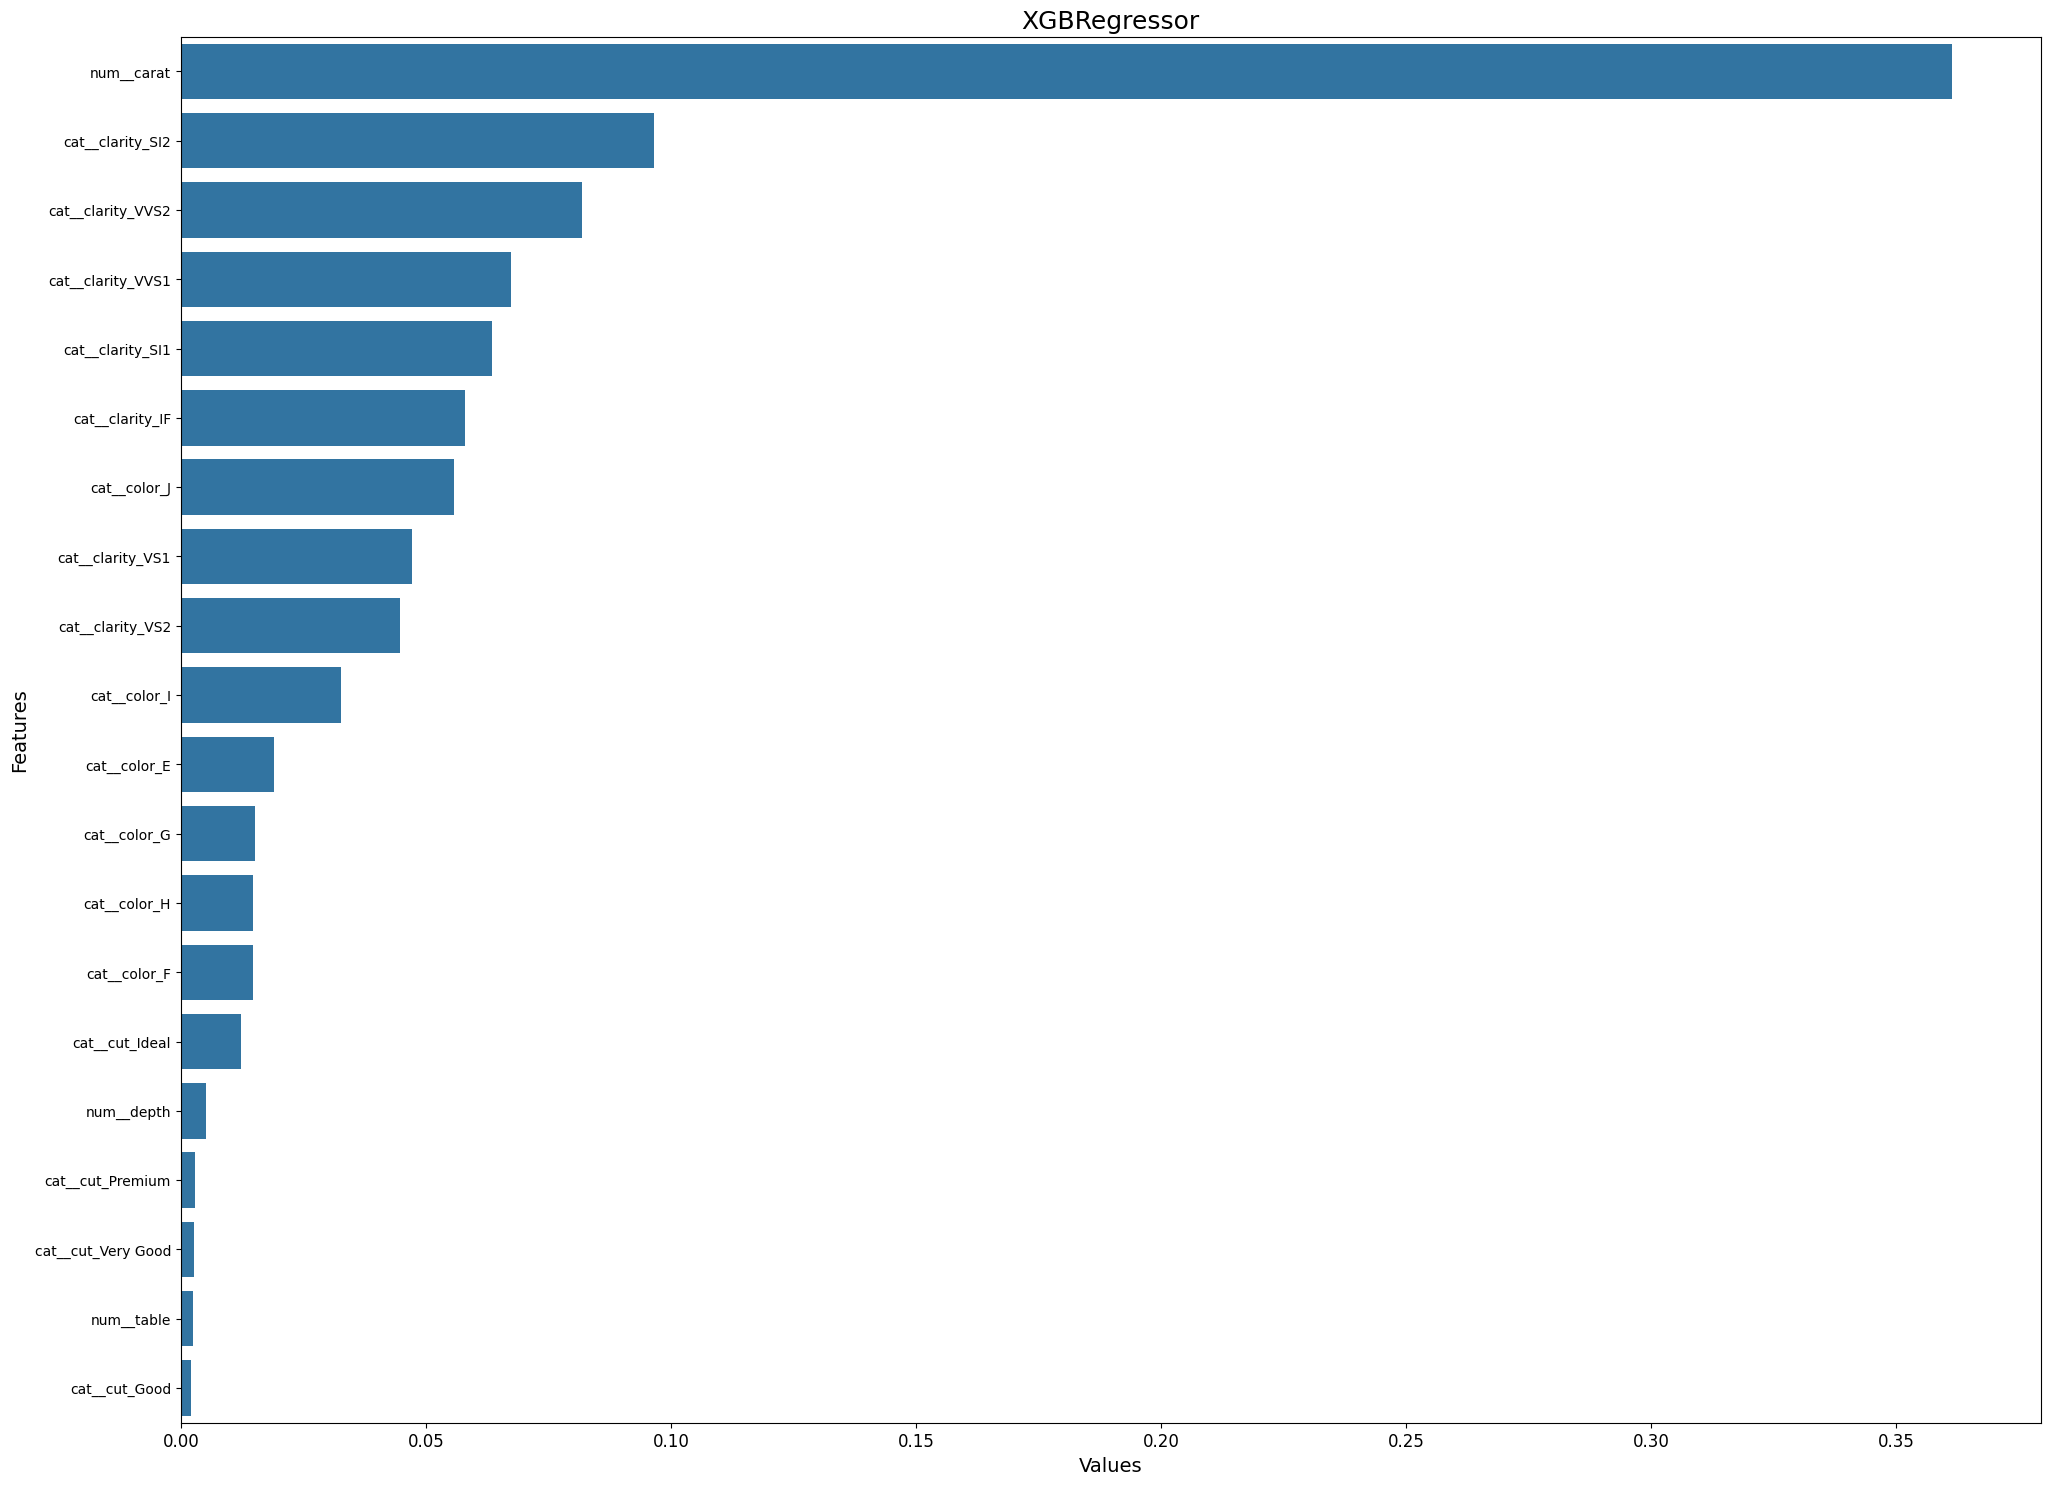

In [6]:
feature_importance_xgb(list_of_models_o)

## ИТОГИ

По результатам обучения моделей можно видно, что лучшие метрики получаются при использовании TargetEncoding. Будем использовать этот метод при тюнинге гиперпараметров на следующем шаге.